In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1222


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g140m-f100lp, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [28]:
averager=FL.SpectrumAverager()
redshift_list=[]
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator(), total=len(DJAv4Catalog.catalog)):
    if not catalog['sample_flag']:
        continue
    uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
    if uv_slope_value>-2.0:
        continue
    # if catalog['determined_redshift']<5:
    #     continue
    redshift_list.append(catalog['determined_redshift'])

    averager.load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

100%|██████████| 43042/43042 [00:04<00:00, 8702.64it/s] 


In [14]:
np.median(redshift_list)

np.float64(5.7964)

In [4]:
def flux_density(wavelength, flux_lambda, target_region):
    mask = (wavelength >= target_region[0]) & (wavelength <= target_region[1])
    if np.sum(mask) == 0:
        return np.nan
    if np.isnan(flux_lambda[mask]).any():
        return np.nan

    return np.average(flux_lambda[mask],weights=wavelength[mask])

In [5]:
averager.create_common_wavelength_grid(wavelength_range=(650,8000),grid_size=10)

array([ 650.,  660.,  670.,  680.,  690.,  700.,  710.,  720.,  730.,
        740.,  750.,  760.,  770.,  780.,  790.,  800.,  810.,  820.,
        830.,  840.,  850.,  860.,  870.,  880.,  890.,  900.,  910.,
        920.,  930.,  940.,  950.,  960.,  970.,  980.,  990., 1000.,
       1010., 1020., 1030., 1040., 1050., 1060., 1070., 1080., 1090.,
       1100., 1110., 1120., 1130., 1140., 1150., 1160., 1170., 1180.,
       1190., 1200., 1210., 1220., 1230., 1240., 1250., 1260., 1270.,
       1280., 1290., 1300., 1310., 1320., 1330., 1340., 1350., 1360.,
       1370., 1380., 1390., 1400., 1410., 1420., 1430., 1440., 1450.,
       1460., 1470., 1480., 1490., 1500., 1510., 1520., 1530., 1540.,
       1550., 1560., 1570., 1580., 1590., 1600., 1610., 1620., 1630.,
       1640., 1650., 1660., 1670., 1680., 1690., 1700., 1710., 1720.,
       1730., 1740., 1750., 1760., 1770., 1780., 1790., 1800., 1810.,
       1820., 1830., 1840., 1850., 1860., 1870., 1880., 1890., 1900.,
       1910., 1920.,

In [29]:
averager.interpolate_spectra(interpolation_method='linear')

target_region=(1500,2000)
uvflux_densities=[]
for i in range(len(averager.interpolated_fluxes)):
    wavelength = averager.common_wavelength
    flux_lambda = averager.interpolated_fluxes[i]
    fd = flux_density(wavelength, flux_lambda, target_region)
    if np.isnan(fd):
        print("Warning: NaN flux density for spectrum index", i)
    uvflux_densities.append(fd)
uvflux_densities = np.array(uvflux_densities)

normalization_point=np.median(uvflux_densities)
normalization_factor = normalization_point / uvflux_densities

normalized_fluxes = []

for i in range(len(averager.interpolated_fluxes)):
    normalized_fluxes.append(averager.interpolated_fluxes[i] * normalization_factor[i])

averager.normalized_fluxes = np.array(normalized_fluxes).copy()

In [25]:
np.median(uvflux_densities)

np.float64(7.598181760574052e-20)

In [30]:
averager.compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
# averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)


(array([1381.00352923, 1391.11080087, 1401.2180725 , 1411.32534414,
        1421.43261578, 1431.53988741, 1441.64715905, 1451.75443069,
        1461.86170232, 1471.96897396, 1482.0762456 , 1492.18351723,
        1502.29078887, 1512.3980605 , 1522.50533214, 1532.61260378,
        1542.71987541, 1552.82714705, 1562.93441869, 1573.04169032,
        1583.14896196, 1593.2562336 , 1603.36350523, 1613.47077687,
        1623.57804851, 1633.68532014, 1643.79259178, 1653.89986342,
        1664.00713505, 1674.11440669, 1684.22167832, 1694.32894996,
        1704.4362216 , 1714.54349323, 1724.65076487, 1734.75803651,
        1744.86530814, 1754.97257978, 1765.07985142, 1775.18712305,
        1785.29439469, 1795.40166633, 1805.50893796, 1815.6162096 ,
        1825.72348123, 1835.83075287, 1845.93802451, 1856.04529614,
        1866.15256778, 1876.25983942, 1886.36711105, 1896.47438269,
        1906.58165433, 1916.68892596, 1926.7961976 , 1936.90346924,
        1947.01074087, 1957.11801251, 1967.22528

In [17]:
guido_data_dir = pathlib.Path('~/DustCurve/datastorage/zgtr5_AllObjects_RestFrame_full.txt').expanduser()
guido_data = pd.read_csv(guido_data_dir, delim_whitespace=True,header=0)
guido_wavelength=np.array(guido_data['lam'])*u.AA
guido_flux_nu=np.array(guido_data['flux_nu'])*u.nJy

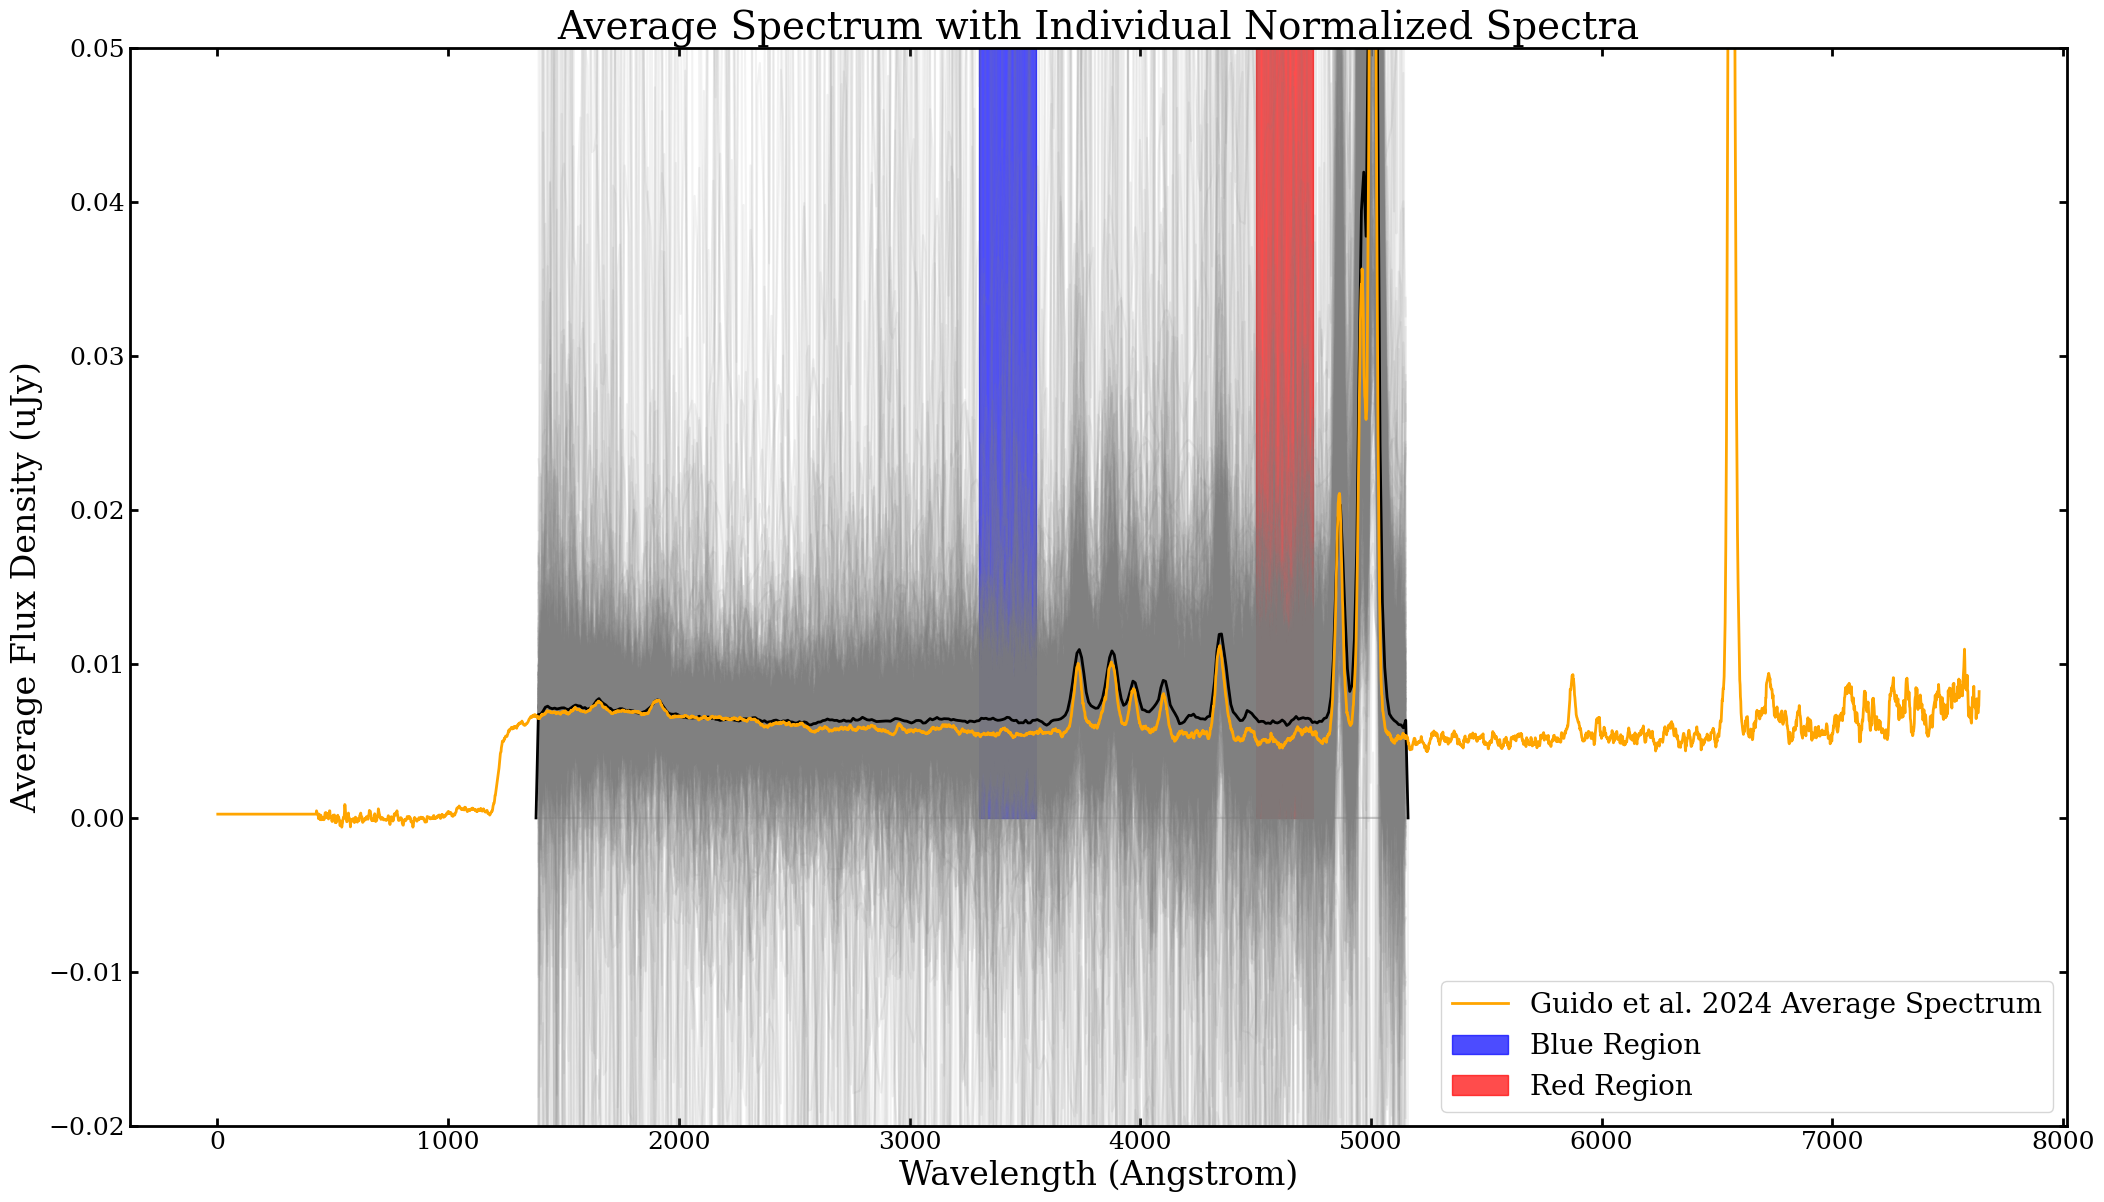

In [31]:
fig, ax = plt.subplots(figsize=(25,14))
for i in range(len(averager.normalized_fluxes)):
    ax.plot(averager.common_wavelength, (averager.normalized_fluxes[i]*u.Unit('erg/s/cm2/AA')).to(u.uJy, equivalencies=u.spectral_density(averager.common_wavelength*u.AA)), color='gray', alpha=0.1)
ax.plot(averager.common_wavelength, (averager.average_flux*u.Unit('erg/s/cm2/AA')).to(u.uJy, equivalencies=u.spectral_density(averager.common_wavelength*u.AA)), color='k', linewidth=2)
plt.plot(guido_wavelength/6.9388999, guido_flux_nu.to(u.uJy)*6.9388999*1., color='orange', linewidth=2, label='Guido et al. 2024 Average Spectrum')
ax.set_xlabel('Wavelength (Angstrom)', fontsize=24)
ax.set_ylabel('Average Flux Density (uJy)', fontsize=24)
ax.set_title('Average Spectrum with Individual Normalized Spectra', fontsize=28)

ax.set_ylim(-0.02,0.05)

ax.fill_betweenx(y=[0,0.05], x1=3300,x2=3550, color='blue', alpha=0.7, label='Blue Region')
ax.fill_betweenx(y=[0,0.05], x1=4500,x2=4750, color='red', alpha=0.7, label='Red Region')

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.legend(fontsize=20, loc='best')
